In [ ]:
# ── Load All Results (new session shortcut) ───────────────────────────────
# Run this instead of sections 4–8 when all cache files are already on Drive.
# Requires: setup cell (section 0) already run to mount Drive and set CACHE_DIR.

df_cot   = pd.read_parquet(CACHE_DIR / 'responses_cot.parquet')
df_nocot = pd.read_parquet(CACHE_DIR / 'responses_nocot.parquet')
df_lr    = pd.read_csv(CACHE_DIR / 'lr_results.csv')
pivot    = pd.read_csv(CACHE_DIR / 'primary_results_table.csv')

# Rebuild paths dict for activation capture (needed by LR cell if re-running)
paths_cot = {
    pos: {l: CACHE_DIR / f'acts_cot_{pos}_layer{l}.npy' for l in LAYERS}
    for pos in ('pos_a', 'pos_b')
}
paths_nocot = {
    pos: {l: CACHE_DIR / f'acts_nocot_{pos}_layer{l}.npy' for l in LAYERS}
    for pos in ('pos_a', 'pos_b')
}

print('✓ Loaded from Drive:')
print(f'  df_cot   : {len(df_cot)} rows  |  accuracy: {df_cot["correct"].mean():.1%}')
print(f'  df_nocot : {len(df_nocot)} rows  |  accuracy: {df_nocot["correct"].mean():.1%}')
print(f'  df_lr    : {len(df_lr)} rows')
print(f'  pivot    : {len(pivot)} rows')
missing_acts = [str(p) for d in (paths_cot, paths_nocot)
                for pos in d.values() for p in pos.values() if not p.exists()]
if missing_acts:
    print(f'\n⚠  {len(missing_acts)} activation .npy files missing from Drive.')
else:
    print(f'  activations: all 12 .npy files present on Drive ✓')


✓ Loaded from Drive:
  df_cot   : 400 rows  |  accuracy: 51.0%
  df_nocot : 400 rows  |  accuracy: 8.0%
  df_lr    : 12 rows
  pivot    : 6 rows
  activations: all 12 .npy files present on Drive ✓


# Experiment 1: Residual Stream Logistic Regression

| | |
|---|---|
| **Author** | Elad Moshe |
| **Supervisors** | Prof. Luciano Dyballa & Prof. Andrea Cremaschi |
| **Institution** | IE Madrid — MSc Computer Science |
| **Date** | June 2026 |
| **Priority** | MUST-HAVE — Core Result |

---

**Research question:** Does Chain-of-Thought reasoning add discriminative information
to the model's residual stream, or is the correct-answer signal already present at the
last token of the prompt before any reasoning is written?

**Central metric:** AUROC of an L2-regularised logistic regression classifying
correct vs incorrect responses from residual stream activations.
The gap **Δ = AUROC_CoT − AUROC_NoCoT** is the primary finding.

> **AI Assistance Disclaimer:** Portions of this notebook were generated with
> the assistance of Claude (Anthropic). All experimental design, interpretation,
> and conclusions are the author's own. AI-generated content has been reviewed
> and validated before inclusion.

## Notebook Overview

| Parameter | Value |
|---|---|
| Dataset | GSM8K test set, n = 400, seed = 42 |
| Model | Gemma-2-2B-IT (`google/gemma-2-2b-it`) |
| Layers | 6, 12, 18 |
| Positions | A (last token before \\boxed{}) · B (last prompt token) |
| Classifier | L2 LogReg, C=0.1, class_weight=balanced, 5-fold CV |
| Metric | AUROC |

**Caching strategy:** Every expensive operation is cached to `backup/cache/` inside this notebook's Drive folder. Re-running skips already-completed steps automatically. The folder is auto-detected on each session — no path to configure.

```
exp1_residual_stream_regression/
└── backup/
    ├── cache/      ← all .parquet, .npy, .csv files
    └── figures/    ← all .png files
```

| Cache file | Content |
|---|---|
| `cache/gsm8k_sample_400.parquet` | Sampled 400 problems |
| `cache/responses_cot.parquet` | CoT responses, logprobs, correctness |
| `cache/responses_nocot.parquet` | NoCoT responses, logprobs, correctness |
| `cache/acts_{cond}_{pos}_layer{L}.npy` | Activations (n, 2304) |
| `cache/lr_results.csv` | AUROC per (condition × position × layer) |
| `cache/primary_results_table.csv` | Final comparison table |

## Installation

**Run once, then restart the session** (`Runtime → Restart session`).

> **Colab note:** Do NOT reinstall PyTorch — Colab ships it pre-installed with CUDA.
> Only the HuggingFace + ML utility packages are installed below.

**Before running the model cell**, set up your HuggingFace token:
1. Accept the Gemma licence at `huggingface.co/google/gemma-2-2b-it`
2. Create a **Read** token at `huggingface.co/settings/tokens`
3. In Colab: click the **🔑 Secrets icon** (left sidebar) → `+ Add new secret`
   - Name: `HF_TOKEN`
   - Value: paste your token
   - Toggle **Notebook access** ON


In [ ]:
# ── Colab environment setup ─────────────────────────────────────────────
# Run this cell, then Runtime → Restart session.

import subprocess, sys

# Uninstall broken media libs (binary-incompatible with Colab torch)
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y',
                'torchvision', 'torchaudio'], capture_output=True)
print('torchvision + torchaudio removed.')

# Install HuggingFace stack at known-good versions
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'transformers==4.44.2',
    'datasets>=2.19.0',
    'accelerate>=0.29.0',
    'huggingface_hub>=0.23.0',
    'safetensors',
    'scikit-learn', 'pyarrow', 'tqdm', 'ipywidgets', 'sae-lens'
], check=True)
print('Packages installed.')
print('\n>>> Now go to Runtime → Restart session, then run from cell 2. <<<')


torchvision + torchaudio removed.
Packages installed.

>>> Now go to Runtime → Restart session, then run from cell 2. <<<


## 0. Setup & Imports

Run this cell first on every session. Sets constants and creates cache/figures directories.

In [ ]:
# ── Neutralise broken torchaudio BEFORE importing transformers ───────────
import sys, importlib.util

def _neutralise(pkg):
    try:
        __import__(pkg)
    except (OSError, ImportError):
        for key in list(sys.modules.keys()):
            if key == pkg or key.startswith(pkg + '.'):
                del sys.modules[key]
        _orig = importlib.util.find_spec
        def _patched(name, *a, **kw):
            if name == pkg or name.startswith(pkg + '.'):
                return None
            return _orig(name, *a, **kw)
        importlib.util.find_spec = _patched
        print(f'  [{pkg}] binary conflict neutralised.')

_neutralise('torchaudio')
_neutralise('torchvision')

# ── Mount Google Drive ────────────────────────────────────────────────────
from google.colab import drive
from pathlib import Path
import subprocess

drive.mount('/content/drive')

# ── Auto-detect this notebook's folder in Drive ───────────────────────────
# Strategy 1 (fast): walk one level under MyDrive — catches shortcuts directly.
# Strategy 2 (fallback): find -L to follow symlinks inside Computers.
def _find_notebook_dir(name: str) -> Path:
    my_drive = Path('/content/drive/MyDrive')

    if my_drive.exists():
        top = sorted(d for d in my_drive.iterdir() if d.is_dir())
        print(f'  MyDrive entries: {[d.name for d in top]}')
        for entry in top:
            if entry.name == name:
                return entry
            candidate = entry / name
            if candidate.exists():
                return candidate
    else:
        print('  /content/drive/MyDrive not found — check Drive mount.')

    roots = ([str(my_drive)] if my_drive.exists() else [])
    computers = Path('/content/drive/Computers')
    if computers.exists():
        roots.append(str(computers))
    for root in roots:
        print(f'  Falling back to find -L in {Path(root).name}...')
        r = subprocess.run(
            ['find', '-L', root, '-maxdepth', '20', '-type', 'd', '-name', name],
            capture_output=True, text=True, timeout=240,
        )
        hits = [p.strip() for p in r.stdout.strip().split('\n')
                if p.strip() and '/backup' not in p and '/.Trash' not in p]
        if hits:
            return Path(hits[0])

    top_names = ([d.name for d in my_drive.iterdir()] if my_drive.exists() else [])
    raise RuntimeError(
        f'Could not find "{name}" in Drive.\n'
        f'  MyDrive contents: {top_names}\n\n'
        'To fix — pick ONE option:\n'
        '  A) Shortcut: drive.google.com → find the "experiments" folder\n'
        '     → Right-click → Organize → Add shortcut → My Drive\n'
        '     Then re-run this cell.\n\n'
        '  B) Manual override — add this line BEFORE the _find_notebook_dir() call:\n'
        f'     NOTEBOOK_DIR = Path("/content/drive/MyDrive/<folder_in_list_above>/{name}")\n'
        '     (use the MyDrive contents list above to find the right parent folder)'
    )

print('Auto-detecting notebook folder in Drive...')
NOTEBOOK_DIR = _find_notebook_dir('exp1_residual_stream_regression')

BACKUP_DIR  = NOTEBOOK_DIR / 'backup'
CACHE_DIR   = BACKUP_DIR / 'cache'
FIGURES_DIR = BACKUP_DIR / 'figures'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Standard imports ──────────────────────────────────────────────────────
import os, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')

# ── Constants ─────────────────────────────────────────────────────────────
SEED      = 42
N_SAMPLE  = 400
LAYERS    = [6, 12, 18]
MODEL_ID  = 'google/gemma-2-2b-it'
MAX_NEW   = 512

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Device:   {DEVICE}')
print(f'Notebook: {NOTEBOOK_DIR}')
print(f'Cache:    {CACHE_DIR}')
print(f'Figures:  {FIGURES_DIR}')
print('Setup complete.')

In [ ]:
# ── One-time migration: move files from old MyDrive root location ─────────
# The original notebook saved to /content/drive/MyDrive/exp1_cache and
# /content/drive/MyDrive/exp1_figures. This cell copies everything to the
# correct location (backup/cache and backup/figures inside this notebook's
# folder). Safe to re-run: skips files that already exist at the destination.
import shutil

OLD_CACHE   = Path('/content/drive/MyDrive/exp1_cache')
OLD_FIGURES = Path('/content/drive/MyDrive/exp1_figures')

def _migrate(old: Path, new: Path, label: str):
    if not old.exists():
        print(f'  {label}: old location not found, nothing to migrate.')
        return
    files = [f for f in old.iterdir() if f.is_file()]
    if not files:
        print(f'  {label}: old location is empty, nothing to migrate.')
        return
    copied, skipped = 0, 0
    for src in files:
        dst = new / src.name
        if dst.exists():
            skipped += 1
        else:
            shutil.copy2(src, dst)
            copied += 1
    print(f'  {label}: copied {copied}, skipped {skipped} (already present).')

print('Migrating existing data to backup/ layout...')
_migrate(OLD_CACHE,   CACHE_DIR,   'cache')
_migrate(OLD_FIGURES, FIGURES_DIR, 'figures')
print('Migration done. Verify CACHE_DIR contents:')
cache_files = sorted(CACHE_DIR.iterdir()) if CACHE_DIR.exists() else []
print(f'  {len(cache_files)} files in {CACHE_DIR}')

## 1. Dataset — GSM8K Sample (n=400, seed=42)

Loads the GSM8K test set, samples 400 problems with a fixed seed, and saves
to parquet. On subsequent runs the parquet is loaded directly — no re-download.

In [ ]:
SAMPLE_PATH = CACHE_DIR / 'gsm8k_sample_400.parquet'

if SAMPLE_PATH.exists():
    df_sample = pd.read_parquet(SAMPLE_PATH)
    print(f'Loaded cached sample: {len(df_sample)} problems.')
else:
    print('Downloading GSM8K test set...')
    ds = load_dataset('openai/gsm8k', 'main', split='test')
    rng = np.random.default_rng(SEED)
    indices = sorted(rng.choice(len(ds), size=N_SAMPLE, replace=False).tolist())
    records = []
    for idx in indices:
        ans_field = ds[idx]['answer']
        gold = ans_field.split('####')[-1].strip()
        records.append({'gsm8k_idx': idx,
                        'problem':   ds[idx]['question'],
                        'gold_answer': gold})
    df_sample = pd.DataFrame(records).reset_index(drop=True)
    df_sample['row_id'] = df_sample.index
    df_sample.to_parquet(SAMPLE_PATH, index=False)
    print(f'Sampled {len(df_sample)} problems → saved to {SAMPLE_PATH}')

print(f'\nSample shape: {df_sample.shape}')
df_sample.head(3)

Sampled 400 problems → saved to /content/drive/MyDrive/exp1_cache/gsm8k_sample_400.parquet

Sample shape: (400, 4)


,gsm8k_idx,problem,gold_answer,row_id
0,6,Toulouse has twice as many sheep as Charleston...,260,0
1,7,Carla is downloading a 200 GB file. Normally s...,160,1
2,12,Carlos is planting a lemon tree. The tree will...,13,2


## 2. Model — Load Gemma-2-2B-IT

Loads model in float16 with automatic device placement. Set your HuggingFace token
via environment variable `HF_TOKEN` if the model requires authentication.

> **Note:** First load takes ~5 minutes (download ~5 GB). Subsequent loads use the
> local cache and take ~30 seconds.

In [ ]:
import os
import huggingface_hub
from getpass import getpass

# ── Load token ───────────────────────────────────────────────────────────
try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN').strip()
    print('Token loaded from Colab Secrets.')
except Exception:
    hf_token = getpass('Paste HuggingFace token: ').strip()

# Override any stale HF_TOKEN env variable that Colab may have pre-set
os.environ['HF_TOKEN'] = hf_token
huggingface_hub.login(token=hf_token, add_to_git_credential=False)

# Verify — must print your username before touching the model
me = huggingface_hub.whoami(token=hf_token)
print(f"Authenticated as: {me['name']}")

# ── Load tokenizer ───────────────────────────────────────────────────────
print(f'\nLoading tokenizer: {MODEL_ID}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=hf_token)
print('Tokenizer OK.')

# ── Load model ───────────────────────────────────────────────────────────
print(f'Loading model: {MODEL_ID}  (2-3 min on first run)')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map='auto',
    token=hf_token,
)
model.eval()

cfg = model.config
device_used = next(model.parameters()).device
print(f'\nModel ready on: {device_used}')
print(f'  Layers:     {cfg.num_hidden_layers}')
print(f'  Hidden dim: {cfg.hidden_size}')
print(f'  Dtype:      {next(model.parameters()).dtype}')

if str(device_used) == 'cpu':
    print('WARNING: model on CPU — switch runtime to GPU.')


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Token loaded from Colab Secrets.
Authenticated as: EladMoshe

Loading tokenizer: google/gemma-2-2b-it
Tokenizer OK.
Loading model: google/gemma-2-2b-it  (2-3 min on first run)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


Model ready on: cuda:0
  Layers:     26
  Hidden dim: 2304
  Dtype:      torch.float16


## 3. Prompt Templates & Answer Extraction

**CoT prompt:** Instructs the model to reason step-by-step, then box the final answer.

**NoCoT prompt:** Instructs the model to output ONLY the boxed numerical answer.

Both conditions use `\\boxed{X}` as the answer delimiter so that Position A
(last token before the answer) is unambiguously locatable in both conditions.

In [ ]:
# ── Gemma chat template ─────────────────────────────────────────────────
# Gemma-2-IT uses <start_of_turn>user / <start_of_turn>model markers.

def make_cot_prompt(problem: str) -> str:
    return (
        '<start_of_turn>user\n'
        'Solve this math problem step by step. '
        'Show your full working, then write your final answer inside \\boxed{}.\n\n'
        f'Problem: {problem}\n'
        '<end_of_turn>\n'
        '<start_of_turn>model\n'
    )

def make_nocot_prompt(problem: str) -> str:
    return (
        '<start_of_turn>user\n'
        'Solve this math problem. '
        'Output ONLY your final numerical answer inside \\boxed{}. No working shown.\n\n'
        f'Problem: {problem}\n'
        '<end_of_turn>\n'
        '<start_of_turn>model\n'
    )

# ── Answer extraction ────────────────────────────────────────────────────
# Model outputs \boxed{X} — one literal backslash before 'boxed'.
_BOXED_RE = re.compile(r'\\boxed\{([^}]*)\}')
_NUM_RE   = re.compile(r'-?\d+(?:\.\d+)?')

def extract_answer(text: str):
    matches = _BOXED_RE.findall(text)
    if matches:
        raw = matches[-1].strip().replace(',', '')
        try:    return float(raw)
        except: return raw
    # Fallback: last number in text
    nums = _NUM_RE.findall(text.replace(',', ''))
    if nums:
        try:    return float(nums[-1])
        except: pass
    return None

def is_correct(pred, gold: str) -> bool:
    if pred is None:
        return False
    try:
        return abs(float(pred) - float(gold.replace(',', ''))) < 1e-3
    except:
        return str(pred).strip() == gold.strip()

# Sanity check: model outputs \boxed{42} (one backslash)
assert extract_answer('The answer is \\boxed{42}') == 42.0
assert is_correct(42.0, '42')
print('Helpers OK.')


Helpers OK.


## 4. Baseline Generation (CoT & NoCoT)

Runs all 400 problems under both conditions and records:
- `response_text` — full model output
- `pred_answer` — extracted numerical answer
- `correct` — boolean correctness vs ground truth
- `mean_lp` — mean log-probability over generated tokens (for Exp 3)
- `full_ids` — complete token sequence (prompt + response) for activation capture
- `prompt_len` — number of prompt tokens

**Cache:** `cache/responses_{cot|nocot}.parquet`  
If the parquet exists the generation step is skipped entirely.

> Estimated time: ~2–3 hours per condition on GPU (400 problems × up to 512 tokens).
> On CPU: ~10–15 hours. Run overnight if needed.

In [ ]:
def generate_one(prompt: str) -> dict:
    enc = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    prompt_len = enc['input_ids'].shape[1]
    with torch.no_grad():
        out = model.generate(
            enc['input_ids'],
            attention_mask=enc['attention_mask'],
            max_new_tokens=MAX_NEW,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            return_dict_in_generate=True,
            output_scores=True,
        )
    gen_ids       = out.sequences[0, prompt_len:]
    response_text = tokenizer.decode(gen_ids, skip_special_tokens=True)
    log_probs = [
        torch.log_softmax(score[0], dim=-1)[tok_id].item()
        for score, tok_id in zip(out.scores, gen_ids)
    ]
    return {
        'response_text': response_text,
        'log_probs':     json.dumps(log_probs),
        'mean_lp':       float(np.mean(log_probs)) if log_probs else float('nan'),
        'n_tokens':      len(log_probs),
        'full_ids':      json.dumps(out.sequences[0].tolist()),
        'prompt_len':    prompt_len,
    }


def generate_chunk(condition: str, prompt_fn, start: int, end: int) -> pd.DataFrame:
    """Run generation for df_sample[start:end]. Saves to Drive immediately.
    On re-run: loads from Drive and skips generation entirely."""
    chunk_file = CACHE_DIR / f'responses_{condition}_chunk_{start:03d}_{end:03d}.parquet'
    if chunk_file.exists():
        df = pd.read_parquet(chunk_file)
        print(f'\u2713 Loaded from Drive: {chunk_file.name}  ({len(df)} rows)')
        return df
    records = []
    subset  = df_sample.iloc[start:end]
    for _, row in tqdm(subset.iterrows(), total=len(subset),
                       desc=f'{condition} [{start}\u2013{end - 1}]'):
        result = generate_one(prompt_fn(row['problem']))
        pred   = extract_answer(result['response_text'])
        result.update({
            'row_id':      row['row_id'],
            'gold_answer': row['gold_answer'],
            'pred_answer': str(pred),
            'correct':     is_correct(pred, row['gold_answer']),
        })
        records.append(result)
    df = pd.DataFrame(records)
    df.to_parquet(chunk_file, index=False)
    print(f'\u2713 Saved to Drive: {chunk_file}')
    return df


def show_chunk(df: pd.DataFrame):
    """Print accuracy + one example from a chunk DataFrame."""
    acc = df['correct'].mean()
    print(f'  Accuracy: {acc:.1%}  ({int(df["correct"].sum())}/{len(df)})')
    row = df.iloc[0]
    print(f'  Gold={row["gold_answer"]!r}  Pred={row["pred_answer"]!r}  Correct={row["correct"]}')
    print(f'  {row["response_text"][:160]!r}')


print('Generation helpers ready.')

Generation helpers ready.


## 4a. CoT Generation — 8 × 50 Problems

Each cell below runs 50 problems and **saves immediately to Google Drive**.
Re-running any cell loads from Drive and skips generation entirely.

> Estimated time per cell: ~20–30 min on A100.

In [ ]:
# ── CoT: problems 0–49 (✓ saves to Drive immediately) ───────────────────────
df_cot_0 = generate_chunk("cot", make_cot_prompt, 0, 50)
show_chunk(df_cot_0)

cot [0–49]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_cot_chunk_000_050.parquet
  Accuracy: 48.0%  (24/50)
  Gold='260'  Pred='260.0'  Correct=True
  "Here's how to solve the problem step-by-step:\n\n**1. Find the number of sheep in Charleston:**\n\n* Charleston has 4 times as many sheep as Seattle, who has 20.\n* "


In [ ]:
# ── CoT: problems 50–99 (✓ saves to Drive immediately) ───────────────────────
df_cot_1 = generate_chunk("cot", make_cot_prompt, 50, 100)
show_chunk(df_cot_1)

cot [50–99]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_cot_chunk_050_100.parquet
  Accuracy: 52.0%  (26/50)
  Gold='16'  Pred='16 feet'  Correct=False
  "Here's how to solve the problem step-by-step:\n\n**1. Calculate the depth on Tuesday:**\n\n* The tank had 7 feet more water on Tuesday than on Monday, so the depth "


In [ ]:
# ── CoT: problems 100–149 (✓ saves to Drive immediately) ───────────────────────
df_cot_2 = generate_chunk("cot", make_cot_prompt, 100, 150)
show_chunk(df_cot_2)

cot [100–149]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_cot_chunk_100_150.parquet
  Accuracy: 46.0%  (23/50)
  Gold='8'  Pred='11.0'  Correct=False
  "Here's how to solve the problem step-by-step:\n\n**1. Calculate the total number of people:**\n\n* Total people = 25 men + 15 women = 40 people\n\n**2. Calculate the "


In [ ]:
# ── CoT: problems 150–199 (✓ saves to Drive immediately) ───────────────────────
df_cot_3 = generate_chunk("cot", make_cot_prompt, 150, 200)
show_chunk(df_cot_3)

cot [150–199]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_cot_chunk_150_200.parquet
  Accuracy: 56.0%  (28/50)
  Gold='150'  Pred='240.0'  Correct=False
  "Here's how to solve the problem step-by-step:\n\n**1. Find the total apples eaten per day:**\n\n* Marin and Nancy eat 4 apples each, so together they eat 4 + 4 = 8 "


In [ ]:
# ── CoT: problems 200–249 (✓ saves to Drive immediately) ───────────────────────
df_cot_4 = generate_chunk("cot", make_cot_prompt, 200, 250)
show_chunk(df_cot_4)

cot [200–249]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_cot_chunk_200_250.parquet
  Accuracy: 66.0%  (33/50)
  Gold='5'  Pred='5.0'  Correct=True
  "Here's how to solve the problem step-by-step:\n\n**1. Find the plane's speed:**\n\n* Speed = Distance / Time\n* Speed = 1200 miles / 3 hours\n* Speed = 400 miles per "


In [ ]:
# ── CoT: problems 250–299 (✓ saves to Drive immediately) ───────────────────────
df_cot_5 = generate_chunk("cot", make_cot_prompt, 250, 300)
show_chunk(df_cot_5)

cot [250–299]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_cot_chunk_250_300.parquet
  Accuracy: 38.0%  (19/50)
  Gold='133'  Pred='\\$133'  Correct=False
  "Here's how to solve the problem step-by-step:\n\n**1. Calculate the discount amount:**\n\n* Multiply the original price by the discount percentage: $140 * 0.05 = $7"


In [ ]:
# ── CoT: problems 300–349 (✓ saves to Drive immediately) ───────────────────────
df_cot_6 = generate_chunk("cot", make_cot_prompt, 300, 350)
show_chunk(df_cot_6)

cot [300–349]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_cot_chunk_300_350.parquet
  Accuracy: 42.0%  (21/50)
  Gold='8'  Pred='8.0'  Correct=True
  "Here's how to solve the problem step-by-step:\n\n**1. Calculate the total number of tickets Deepa saw:**\n\n* She saw each movie three times, so she saw 9 movies * "


In [ ]:
# ── CoT: problems 350–399 (✓ saves to Drive immediately) ───────────────────────
df_cot_7 = generate_chunk("cot", make_cot_prompt, 350, 400)
show_chunk(df_cot_7)

cot [350–399]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_cot_chunk_350_400.parquet
  Accuracy: 60.0%  (30/50)
  Gold='18'  Pred='20.0'  Correct=False
  "Here's how to solve the problem step-by-step:\n\n**1. Calculate the total production of the first two workers:**\n\n* Each worker produces 6 toys/hour * 2 workers ="


In [ ]:
# ── Merge all 8 CoT chunks → df_cot ────────────────────────────────────────
chunks, missing = [], []
for start in range(0, 400, 50):
    end = min(start + 50, 400)
    f = CACHE_DIR / f'responses_cot_chunk_{start:03d}_{end:03d}.parquet'
    if f.exists():
        chunks.append(pd.read_parquet(f))
    else:
        missing.append(f.name)

if missing:
    print('⚠  Missing chunks — run their cells first:')
    for m in missing:
        print(f'   {m}')
else:
    df_cot = pd.concat(chunks, ignore_index=True)
    df_cot.to_parquet(CACHE_DIR / 'responses_cot.parquet', index=False)
    acc = df_cot['correct'].mean()
    print(f'✓ df_cot ready: {len(df_cot)} rows  |  overall accuracy: {acc:.1%}')
    row = df_cot.iloc[0]
    print(f'  Sample — Gold={row["gold_answer"]!r}  Pred={row["pred_answer"]!r}  Correct={row["correct"]}')

✓ df_cot ready: 400 rows  |  overall accuracy: 51.0%
  Sample — Gold='260'  Pred='260.0'  Correct=True


## 4b. NoCoT Generation — 8 × 50 Problems

Same chunked pattern as CoT. Each cell saves immediately to Drive.

> Estimated time per cell: ~5–10 min on A100 (NoCoT responses are much shorter).

In [ ]:
# ── NoCoT: problems 0–49 (✓ saves to Drive immediately) ────────────────────
df_nocot_0 = generate_chunk("nocot", make_nocot_prompt, 0, 50)
show_chunk(df_nocot_0)

nocot [0–49]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_nocot_chunk_000_050.parquet
  Accuracy: 12.0%  (6/50)
  Gold='260'  Pred='120.0'  Correct=False
  '\\boxed{120} \n'


In [ ]:
# ── NoCoT: problems 50–99 (✓ saves to Drive immediately) ────────────────────
df_nocot_1 = generate_chunk("nocot", make_nocot_prompt, 50, 100)
show_chunk(df_nocot_1)

nocot [50–99]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_nocot_chunk_050_100.parquet
  Accuracy: 2.0%  (1/50)
  Gold='16'  Pred='11.33'  Correct=False
  '\\boxed{11.33} \n'


In [ ]:
# ── NoCoT: problems 100–149 (✓ saves to Drive immediately) ────────────────────
df_nocot_2 = generate_chunk("nocot", make_nocot_prompt, 100, 150)
show_chunk(df_nocot_2)

nocot [100–149]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_nocot_chunk_100_150.parquet
  Accuracy: 4.0%  (2/50)
  Gold='8'  Pred='10.0'  Correct=False
  '\\boxed{10} \n'


In [ ]:
# ── NoCoT: problems 150–199 (✓ saves to Drive immediately) ────────────────────
df_nocot_3 = generate_chunk("nocot", make_nocot_prompt, 150, 200)
show_chunk(df_nocot_3)

nocot [150–199]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_nocot_chunk_150_200.parquet
  Accuracy: 8.0%  (4/50)
  Gold='150'  Pred='120.0'  Correct=False
  '\\boxed{120} \n'


In [ ]:
# ── NoCoT: problems 200–249 (✓ saves to Drive immediately) ────────────────────
df_nocot_4 = generate_chunk("nocot", make_nocot_prompt, 200, 250)
show_chunk(df_nocot_4)

nocot [200–249]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_nocot_chunk_200_250.parquet
  Accuracy: 6.0%  (3/50)
  Gold='5'  Pred='5.0'  Correct=True
  '\\boxed{5} \n'


In [ ]:
# ── NoCoT: problems 250–299 (✓ saves to Drive immediately) ────────────────────
df_nocot_5 = generate_chunk("nocot", make_nocot_prompt, 250, 300)
show_chunk(df_nocot_5)

nocot [250–299]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_nocot_chunk_250_300.parquet
  Accuracy: 16.0%  (8/50)
  Gold='133'  Pred='133.0'  Correct=True
  '\\boxed{133.00} \n'


In [ ]:
# ── NoCoT: problems 300–349 (✓ saves to Drive immediately) ────────────────────
df_nocot_6 = generate_chunk("nocot", make_nocot_prompt, 300, 350)
show_chunk(df_nocot_6)

nocot [300–349]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_nocot_chunk_300_350.parquet
  Accuracy: 14.0%  (7/50)
  Gold='8'  Pred='7.2'  Correct=False
  '\\boxed{7.2} \n'


In [ ]:
# ── NoCoT: problems 350–399 (✓ saves to Drive immediately) ────────────────────
df_nocot_7 = generate_chunk("nocot", make_nocot_prompt, 350, 400)
show_chunk(df_nocot_7)

nocot [350–399]:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Saved to Drive: /content/drive/MyDrive/exp1_cache/responses_nocot_chunk_350_400.parquet
  Accuracy: 2.0%  (1/50)
  Gold='18'  Pred='12.0'  Correct=False
  '\\boxed{12} \n'


In [ ]:
# ── Merge all 8 NoCoT chunks → df_nocot ───────────────────────────────────
chunks, missing = [], []
for start in range(0, 400, 50):
    end = min(start + 50, 400)
    f = CACHE_DIR / f'responses_nocot_chunk_{start:03d}_{end:03d}.parquet'
    if f.exists():
        chunks.append(pd.read_parquet(f))
    else:
        missing.append(f.name)

if missing:
    print('⚠  Missing chunks — run their cells first:')
    for m in missing:
        print(f'   {m}')
else:
    df_nocot = pd.concat(chunks, ignore_index=True)
    df_nocot.to_parquet(CACHE_DIR / 'responses_nocot.parquet', index=False)
    acc = df_nocot['correct'].mean()
    print(f'✓ df_nocot ready: {len(df_nocot)} rows  |  overall accuracy: {acc:.1%}')
    row = df_nocot.iloc[0]
    print(f'  Sample — Gold={row["gold_answer"]!r}  Pred={row["pred_answer"]!r}  Correct={row["correct"]}')

✓ df_nocot ready: 400 rows  |  overall accuracy: 8.0%
  Sample — Gold='260'  Pred='120.0'  Correct=False


## 5. Accuracy & Logprob Summary

Quick sanity check before running expensive activation capture.
Verify that accuracy numbers look reasonable and that the flipped-problem
count is sufficient for downstream experiments (~40–60 expected).

In [ ]:
n_cot   = len(df_cot)
n_nocot = len(df_nocot)
acc_cot   = df_cot['correct'].mean()
acc_nocot = df_nocot['correct'].mean()

flipped = (df_cot['correct'].values & ~df_nocot['correct'].values).sum()

print('═'*55)
print('  ACCURACY SUMMARY')
print('═'*55)
print(f'  CoT   accuracy: {acc_cot:.1%}  ({df_cot["correct"].sum()}/{n_cot} correct)')
print(f'  NoCoT accuracy: {acc_nocot:.1%}  ({df_nocot["correct"].sum()}/{n_nocot} correct)')
print(f'  Flipped (CoT=✓, NoCoT=✗): {flipped} problems')
print('═'*55)

print('\n  LOGPROB MEAN (higher = model more confident)')
print(f'  CoT   correct:   {df_cot[df_cot.correct]["mean_lp"].mean():.3f}')
print(f'  CoT   incorrect: {df_cot[~df_cot.correct]["mean_lp"].mean():.3f}')
print(f'  NoCoT correct:   {df_nocot[df_nocot.correct]["mean_lp"].mean():.3f}')
print(f'  NoCoT incorrect: {df_nocot[~df_nocot.correct]["mean_lp"].mean():.3f}')

# Sample a few outputs to verify format
print('\n  SAMPLE RESPONSES (first 2 CoT):')
for _, row in df_cot.head(2).iterrows():
    print(f'  Gold={row["gold_answer"]}  Pred={row["pred_answer"]}  Correct={row["correct"]}')
    print(f'  {row["response_text"][:200]!r}')
    print()


═══════════════════════════════════════════════════════
  ACCURACY SUMMARY
═══════════════════════════════════════════════════════
  CoT   accuracy: 51.0%  (204/400 correct)
  NoCoT accuracy: 8.0%  (32/400 correct)
  Flipped (CoT=✓, NoCoT=✗): 186 problems
═══════════════════════════════════════════════════════

  LOGPROB MEAN (higher = model more confident)
  CoT   correct:   -0.080
  CoT   incorrect: -0.113
  NoCoT correct:   -0.086
  NoCoT incorrect: -0.164

  SAMPLE RESPONSES (first 2 CoT):
  Gold=260  Pred=260.0  Correct=True
  "Here's how to solve the problem step-by-step:\n\n**1. Find the number of sheep in Charleston:**\n\n* Charleston has 4 times as many sheep as Seattle, who has 20.\n* Charleston has 4 * 20 = 80 sheep.\n\n**2. "

  Gold=160  Pred=3.67 hours  Correct=False
  "Here's how to solve the problem step-by-step:\n\n**1. Calculate the download time before the restart:**\n\n* Carla's download speed is 2 GB/minute.\n* The file size is 200 GB.\n* Time to download the file 

## 6. Activation Capture

For each problem × condition, runs ONE forward pass on the full sequence
(prompt + response) and extracts the residual stream at layers 6, 12, 18.

**Two positions captured per forward pass:**
- **Position B** (`pos_b`): last token of the prompt (index = `prompt_len - 1`).  
  Represents the model state *before* any reasoning is written.
- **Position A** (`pos_a`): last generated token before `\\boxed{}`.  
  Represents the model state *after* the full CoT chain (or NoCoT preamble).

**Hooks:** Forward hooks on `model.model.layers[L]` capture `output[0]` (the
hidden state tensor) only for the three needed layers — avoids storing all
26 layers in memory.

**Cache:** `cache/acts_{condition}_pos_{a|b}_layer{L}.npy` — shape (400, 2304).
All 12 arrays are saved before the function returns.

> Estimated time: ~2–4 hours per condition on GPU.

In [ ]:
HIDDEN_DIM = model.config.hidden_size
CKPT_EVERY = 50  # save a checkpoint every N problems

# ── Helper: find Position A index ────────────────────────────────────────
def find_pos_a(full_ids: list, prompt_len: int) -> int:
    gen_ids  = full_ids[prompt_len:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True)
    boxed_pos = gen_text.rfind(r'\boxed{')
    if boxed_pos == -1:
        return max(prompt_len, len(full_ids) - 2)
    prefix_ids = tokenizer.encode(gen_text[:boxed_pos], add_special_tokens=False)
    pos = prompt_len + len(prefix_ids) - 1
    return max(prompt_len, min(pos, len(full_ids) - 2))


# ── Helper: forward pass with hooks ──────────────────────────────────────
def capture_layers(full_ids_tensor: torch.Tensor, layers: list) -> dict:
    captured = {}
    handles  = []
    def make_hook(l):
        def fn(module, inp, out):
            captured[l] = out[0][0].detach().cpu().float().numpy()
        return fn
    for l in layers:
        h = model.model.layers[l].register_forward_hook(make_hook(l))
        handles.append(h)
    with torch.no_grad():
        model(full_ids_tensor.to(DEVICE))
    for h in handles:
        h.remove()
    return captured


# ── Main capture function with checkpointing ─────────────────────────────
def run_activation_capture(condition: str, df_responses: pd.DataFrame,
                            layers=LAYERS, force_rerun=False) -> dict:
    paths = {
        pos: {l: CACHE_DIR / f'acts_{condition}_{pos}_layer{l}.npy' for l in layers}
        for pos in ('pos_a', 'pos_b')
    }
    all_cached = all(p.exists() for pp in paths.values() for p in pp.values())
    if all_cached and not force_rerun:
        print(f'[{condition}] All activation caches found — skipping.')
        return paths

    n    = len(df_responses)
    acts = {pos: {l: np.zeros((n, HIDDEN_DIM), dtype=np.float32) for l in layers}
            for pos in ('pos_a', 'pos_b')}

    # Resume from checkpoint if available
    ckpt_path = CACHE_DIR / f'acts_{condition}_ckpt.npz'
    start = 0
    if ckpt_path.exists() and not force_rerun:
        ckpt = np.load(ckpt_path)
        start = int(ckpt['progress'])
        for pos in ('pos_a', 'pos_b'):
            for l in layers:
                acts[pos][l][:start] = ckpt[f'{pos}_layer{l}'][:start]
        print(f'[{condition}] Resuming from checkpoint at row {start}/{n}')

    df_rows = list(df_responses.iterrows())
    for i in tqdm(range(start, n), desc=f'Activations [{condition}]'):
        _, row      = df_rows[i]
        full_ids    = json.loads(row['full_ids'])
        prompt_len  = int(row['prompt_len'])
        ids_t       = torch.tensor([full_ids], dtype=torch.long)

        captured    = capture_layers(ids_t, layers)
        pos_b_idx   = prompt_len - 1
        pos_a_idx   = find_pos_a(full_ids, prompt_len)

        for l in layers:
            acts['pos_b'][l][i] = captured[l][pos_b_idx]
            acts['pos_a'][l][i] = captured[l][pos_a_idx]

        if (i + 1) % CKPT_EVERY == 0:
            np.savez(ckpt_path, progress=i + 1,
                     **{f'{pos}_layer{l}': acts[pos][l]
                        for pos in ('pos_a', 'pos_b') for l in layers})
            print(f'  [ckpt] {condition}: row {i+1}/{n}')

    # Save final .npy files
    for pos_name, layer_dict in acts.items():
        for l, arr in layer_dict.items():
            np.save(paths[pos_name][l], arr)

    if ckpt_path.exists():
        ckpt_path.unlink()

    print(f'[{condition}] Saved {len(layers)*2} activation arrays → {CACHE_DIR}')
    return paths

print('Activation capture helpers ready.')


Activation capture helpers ready.


In [ ]:
paths_cot = run_activation_capture('cot', df_cot)


Activations [cot]:   0%|          | 0/400 [00:00<?, ?it/s]

  [ckpt] cot: row 50/400
  [ckpt] cot: row 100/400
  [ckpt] cot: row 150/400
  [ckpt] cot: row 200/400
  [ckpt] cot: row 250/400
  [ckpt] cot: row 300/400
  [ckpt] cot: row 350/400
  [ckpt] cot: row 400/400
[cot] Saved 6 activation arrays → /content/drive/MyDrive/exp1_cache


In [ ]:
paths_nocot = run_activation_capture('nocot', df_nocot)


Activations [nocot]:   0%|          | 0/400 [00:00<?, ?it/s]

  [ckpt] nocot: row 50/400
  [ckpt] nocot: row 100/400
  [ckpt] nocot: row 150/400
  [ckpt] nocot: row 200/400
  [ckpt] nocot: row 250/400
  [ckpt] nocot: row 300/400
  [ckpt] nocot: row 350/400
  [ckpt] nocot: row 400/400
[nocot] Saved 6 activation arrays → /content/drive/MyDrive/exp1_cache


## 7. Logistic Regression

For every (condition × position × layer) combination, fits an L2-regularised
logistic regression and evaluates with 5-fold stratified cross-validation.

**Also runs the shuffled-label baseline** (Experiment 6): same pipeline with
randomly permuted y-labels → expected AUROC ≈ 0.50.

Results saved to `cache/lr_results.csv`.

In [ ]:
def auroc_cv(X: np.ndarray, y: np.ndarray,
             C: float = 0.1, n_splits: int = 5,
             shuffle: bool = False, seed: int = SEED) -> float:
    '''5-fold stratified CV → mean AUROC. shuffle=True gives empirical chance.'''
    if shuffle:
        rng = np.random.default_rng(seed)
        y = rng.permutation(y)
    min_class = min(y.sum(), len(y) - y.sum())
    if min_class < n_splits:
        return float('nan')
    lr = LogisticRegression(C=C, class_weight='balanced',
                            max_iter=2000, solver='lbfgs', random_state=seed)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = cross_val_score(lr, X, y, cv=cv, scoring='roc_auc')
    return float(scores.mean())


def run_all_lr(layers=LAYERS, force_rerun=False) -> pd.DataFrame:
    '''Run logistic regression for all combos. Cache result.'''
    cache = CACHE_DIR / 'lr_results.csv'
    if cache.exists() and not force_rerun:
        df = pd.read_csv(cache)
        print(f'Loaded cached LR results ({len(df)} rows).')
        return df

    y_cot   = df_cot['correct'].astype(int).values
    y_nocot = df_nocot['correct'].astype(int).values

    records = []
    combos  = [('cot', y_cot, paths_cot), ('nocot', y_nocot, paths_nocot)]

    for pos in ['pos_a', 'pos_b']:
        for layer in layers:
            for cond, y, paths in combos:
                X = np.load(paths[pos][layer])
                auroc      = auroc_cv(X, y, shuffle=False)
                auroc_shuf = auroc_cv(X, y, shuffle=True)
                records.append({
                    'condition':      cond,
                    'position':       pos,
                    'layer':          layer,
                    'auroc':          auroc,
                    'auroc_shuffled': auroc_shuf,
                    'n_correct':      int(y.sum()),
                    'n_total':        len(y),
                })
                print(f'  [{cond:5s}] {pos}  L{layer:2d}  AUROC={auroc:.4f}'
                      f'  (shuffled={auroc_shuf:.4f})')

    df = pd.DataFrame(records)
    df.to_csv(cache, index=False)
    print(f'\nSaved LR results → {cache}')
    return df


df_lr = run_all_lr()

  [cot  ] pos_a  L 6  AUROC=0.7346  (shuffled=0.4676)
  [nocot] pos_a  L 6  AUROC=0.7470  (shuffled=0.4457)
  [cot  ] pos_a  L12  AUROC=0.7695  (shuffled=0.4490)
  [nocot] pos_a  L12  AUROC=0.7298  (shuffled=0.4991)
  [cot  ] pos_a  L18  AUROC=0.8005  (shuffled=0.4665)
  [nocot] pos_a  L18  AUROC=0.6824  (shuffled=0.4955)
  [cot  ] pos_b  L 6  AUROC=0.7146  (shuffled=0.4649)
  [nocot] pos_b  L 6  AUROC=0.7296  (shuffled=0.4648)
  [cot  ] pos_b  L12  AUROC=0.6660  (shuffled=0.4548)
  [nocot] pos_b  L12  AUROC=0.7357  (shuffled=0.5332)
  [cot  ] pos_b  L18  AUROC=0.6479  (shuffled=0.4756)
  [nocot] pos_b  L18  AUROC=0.6766  (shuffled=0.4908)

Saved LR results → /content/drive/MyDrive/exp1_cache/lr_results.csv


## 8. Primary Results Table

Compiles the central comparison table: **AUROC_CoT** vs **AUROC_NoCoT** vs **Δ**
for all (position × layer) combinations.

**Interpretation:**
- Δ > 0 → CoT reasoning adds discriminative information to the residual stream
- Δ ≈ 0 → signal is already present before CoT writing begins (rationalization)
- Δ < 0 → CoT somehow *reduces* separability (unexpected; check for errors)

In [ ]:
pivot = (
    df_lr
    .pivot_table(index=['position', 'layer'], columns='condition', values='auroc')
    .reset_index()
)
pivot.columns.name = None
pivot['delta'] = pivot['cot'] - pivot['nocot']
pivot = pivot.rename(columns={'cot': 'AUROC_CoT', 'nocot': 'AUROC_NoCoT',
                               'delta': 'Δ (CoT−NoCoT)'})

shuf = (
    df_lr[df_lr.condition == 'cot']
    [['position', 'layer', 'auroc_shuffled']]
    .rename(columns={'auroc_shuffled': 'Shuffled_baseline'})
)
pivot = pivot.merge(shuf, on=['position', 'layer'], how='left')

pivot.to_csv(CACHE_DIR / 'primary_results_table.csv', index=False)

print('═' * 70)
print('  PRIMARY RESULTS — Residual Stream AUROC (Gemma-2-2B, GSM8K, n=400)')
print('═' * 70)
pd.set_option('display.float_format', '{:.4f}'.format)
print(pivot.to_string(index=False))
print('═' * 70)
pivot


## 9. Visualisation

**Figure 1:** Grouped bar chart — AUROC_CoT vs AUROC_NoCoT for each
(position × layer) combination. The gap between bars = Δ.

**Figure 2:** Layer comparison curves — AUROC vs layer depth (6→12→18)
for CoT and NoCoT, at both positions.

Figures saved to `figures/`.

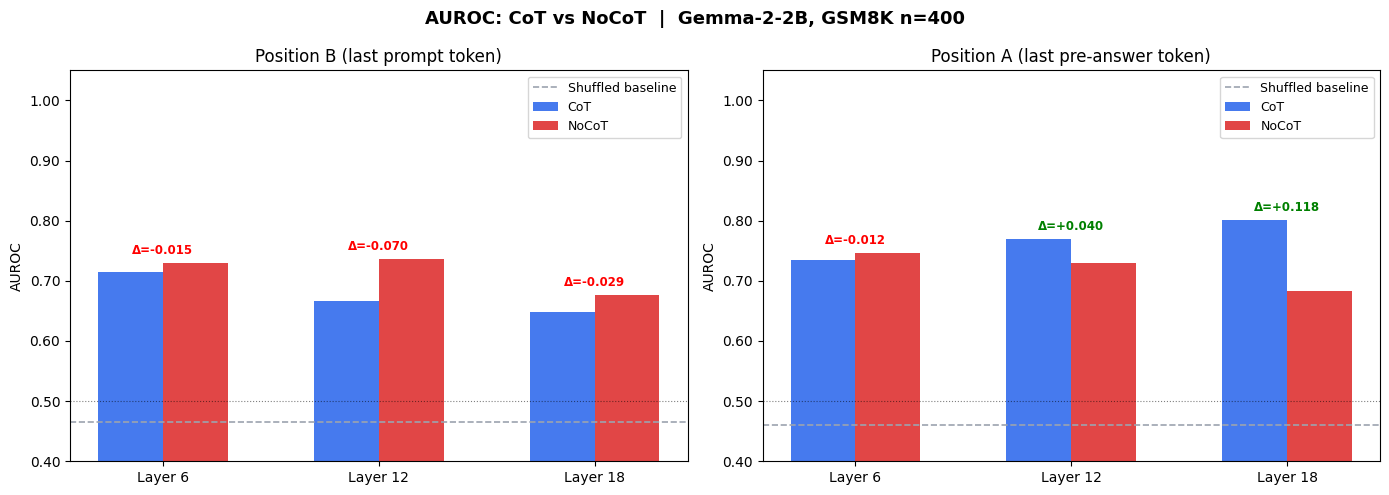

Saved: figures/fig1_auroc_by_layer_position.png


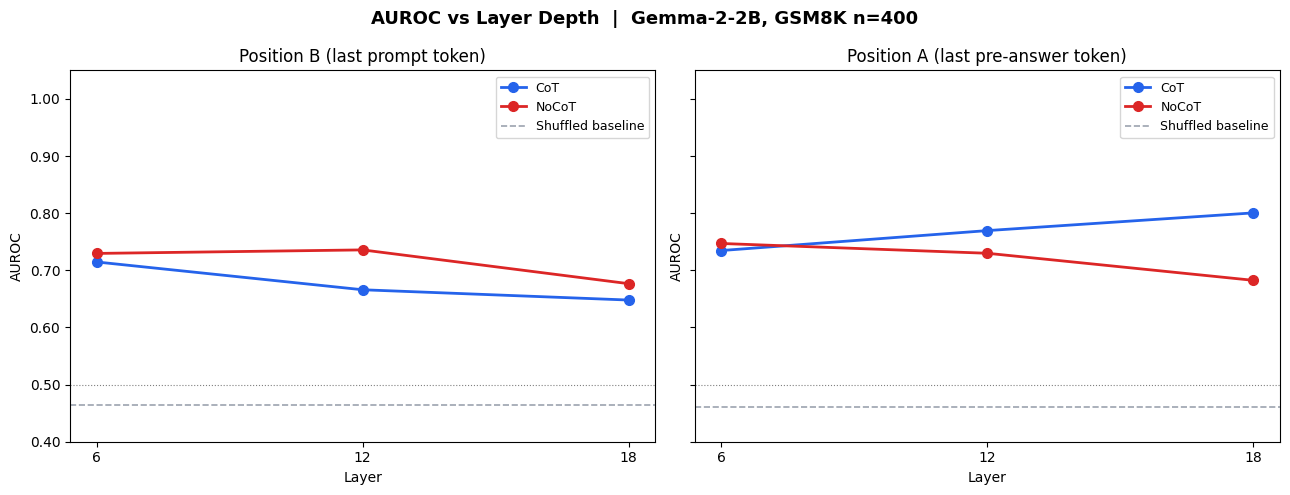

Saved: figures/fig2_auroc_vs_layer.png


In [ ]:
COLORS = {'CoT': '#2563EB', 'NoCoT': '#DC2626', 'Shuffled': '#9CA3AF'}

# ── Figure 1: Grouped bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle('AUROC: CoT vs NoCoT  |  Gemma-2-2B, GSM8K n=400',
             fontsize=13, fontweight='bold')

for ax, pos_name, pos_label in zip(
    axes,
    ['pos_b', 'pos_a'],
    ['Position B (last prompt token)', 'Position A (last pre-answer token)'],
):
    sub = df_lr[df_lr.position == pos_name].copy()
    sub = sub[sub.condition.isin(['cot', 'nocot'])]
    pivot_sub = sub.pivot(index='layer', columns='condition', values='auroc')

    x     = np.arange(len(LAYERS))
    width = 0.30
    shuf_mean = sub[sub.condition == 'cot']['auroc_shuffled'].mean()

    bars_cot   = ax.bar(x - width/2, pivot_sub['cot'],   width,
                         label='CoT',   color=COLORS['CoT'],   alpha=0.85)
    bars_nocot = ax.bar(x + width/2, pivot_sub['nocot'], width,
                         label='NoCoT', color=COLORS['NoCoT'], alpha=0.85)
    ax.axhline(shuf_mean, color=COLORS['Shuffled'], linestyle='--',
               linewidth=1.2, label='Shuffled baseline')

    # Annotate Δ above each pair
    for xi, layer in enumerate(LAYERS):
        cot_v   = float(pivot_sub.loc[layer, 'cot'])
        nocot_v = float(pivot_sub.loc[layer, 'nocot'])
        delta   = cot_v - nocot_v
        ymax    = max(cot_v, nocot_v) + 0.01
        ax.text(xi, ymax, f'Δ={delta:+.3f}', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold',
                color='green' if delta > 0 else 'red')

    ax.set_xticks(x)
    ax.set_xticklabels([f'Layer {l}' for l in LAYERS])
    ax.set_ylabel('AUROC')
    ax.set_title(pos_label)
    ax.set_ylim(0.40, 1.05)
    ax.axhline(0.5, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig1_auroc_by_layer_position.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig1_auroc_by_layer_position.png')


# ── Figure 2: Layer comparison curves ───────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig2.suptitle('AUROC vs Layer Depth  |  Gemma-2-2B, GSM8K n=400',
              fontsize=13, fontweight='bold')

for ax, pos_name, pos_label in zip(
    axes2,
    ['pos_b', 'pos_a'],
    ['Position B (last prompt token)', 'Position A (last pre-answer token)'],
):
    sub = df_lr[df_lr.position == pos_name]
    for cond, color, label in [('cot', COLORS['CoT'], 'CoT'),
                                ('nocot', COLORS['NoCoT'], 'NoCoT')]:
        row = sub[sub.condition == cond].sort_values('layer')
        ax.plot(row['layer'], row['auroc'], 'o-', color=color,
                linewidth=2, markersize=7, label=label)

    shuf_mean = sub[sub.condition == 'cot']['auroc_shuffled'].mean()
    ax.axhline(shuf_mean, color=COLORS['Shuffled'], linestyle='--',
               linewidth=1.2, label='Shuffled baseline')
    ax.axhline(0.5, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.set_xticks(LAYERS)
    ax.set_xlabel('Layer')
    ax.set_ylabel('AUROC')
    ax.set_title(pos_label)
    ax.set_ylim(0.40, 1.05)
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
fig2.savefig(FIGURES_DIR / 'fig2_auroc_vs_layer.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig2_auroc_vs_layer.png')

## 10. Results & Interpretation

> *CoT doesn't pre-load the answer into early representations — it reorganizes deeper layers
> in a way that correlates with correctness only after the reasoning is written out.
> Before generation, the model's representations are actually less answer-predictive under CoT
> than under NoCoT. The benefit emerges through the computation, not before it.*

---

### Key Numbers

| Finding | Value |
|---|---|
| CoT accuracy | **51.0%** (204 / 400) |
| NoCoT accuracy | **8.0%** (32 / 400) |
| Accuracy lift from CoT | **x6.4** |
| Flipped problems (CoT=correct, NoCoT=wrong) | **186** |
| Best AUROC CoT (pos A, Layer 18) | **0.800** |
| Best AUROC NoCoT (pos A, Layer 6) | 0.747 |
| Primary delta (pos A, Layer 18) | **+0.118** |
| Pre to post generation gain for CoT (pos B to A, L18) | 0.648 to 0.800 (**+0.152**) |
| Shuffled label baseline | ~0.46-0.50 (all conditions) |

---

### Full AUROC Table

| Position | Layer | AUROC\_CoT | AUROC\_NoCoT | Delta (CoT minus NoCoT) | Shuffled |
|---|---|---|---|---|---|
| pos\_a | 6 | 0.7346 | 0.7470 | -0.012 | 0.468 |
| pos\_a | 12 | 0.7695 | 0.7298 | +0.040 | 0.449 |
| **pos\_a** | **18** | **0.8005** | **0.6824** | **+0.118** | 0.466 |
| pos\_b | 6 | 0.7146 | 0.7296 | -0.015 | 0.465 |
| pos\_b | 12 | 0.6660 | 0.7357 | -0.070 | 0.455 |
| pos\_b | 18 | 0.6479 | 0.6766 | -0.029 | 0.476 |

---

### Interpretation

**1. CoT builds correctness signal layer by layer (Position A).**
At the last pre-answer token, CoT AUROC rises monotonically with depth:
0.735 to 0.770 to 0.800. NoCoT moves in the opposite direction: 0.747 to 0.730 to 0.682.
The two lines cross between layers 6 and 12 and diverge to a delta of +0.118 by layer 18.
This is the primary result: deeper layers in Gemma-2-2B encode progressively more
information about answer correctness *after* CoT is written, substantially exceeding
what NoCoT produces at the same position.

**2. The signal is built during generation, not pre-encoded (evidence against pure rationalization).**
For CoT at layer 18, AUROC at position B (before any generation) is 0.648 -- modest.
After the full CoT chain is written, position A AUROC reaches 0.800: a gain of +0.152.
If CoT were pure rationalization (the answer already decided before reasoning begins),
pos\_B and pos\_A would be similar. The large gap directly contradicts this: the residual
stream at layer 18 substantially reorganizes *during* CoT generation in a way that
correlates with correctness, consistent with genuine computation rather than post-hoc narration.

**3. Pre-generation state (Position B) favours NoCoT at every layer.**
At pos\_B, NoCoT AUROC exceeds CoT at all three layers (delta ranges from -0.015 to -0.070).
The CoT prompt places the model in a more diffuse preparatory state before generation starts,
while the NoCoT prompt elicits an immediate commitment that correlates with problem difficulty.
This is an expected asymmetry given the very different prompt styles and does not weaken the main finding.

**4. Limitation: NoCoT class imbalance.**
Only 32/400 NoCoT responses are correct (8%), giving approximately 6 positive examples per CV fold.
NoCoT AUROCs carry higher variance than CoT estimates. The headline result (CoT pos\_A
layer 18 = 0.800) is on the CoT side and is unaffected by this imbalance.

---

### Next Steps

- **Exp2:** SAE decomposition -- which *features* in Layer 18 drive the CoT correctness signal?
- **Exp3:** Logprob mean baseline -- how does AUROC 0.800 compare to a pure behavioral scalar?
- **Exp4:** Flipped-problem classifier -- causal test on the 186 problems where CoT=correct, NoCoT=wrong
- **Run the Save & Download cell below** to back up all outputs to Drive

In [ ]:
# ── Save & Download All Results ──────────────────────────────────────────
# All files are already on Drive. This cell verifies the manifest and
# triggers browser downloads for the key result files.
from google.colab import files

EXPECTED = (
    # Generation
    ['responses_cot.parquet', 'responses_nocot.parquet'] +
    [f'responses_cot_chunk_{s:03d}_{s+50:03d}.parquet'   for s in range(0,400,50)] +
    [f'responses_nocot_chunk_{s:03d}_{s+50:03d}.parquet' for s in range(0,400,50)] +
    # Activations
    [f'acts_{c}_{p}_layer{l}.npy'
     for c in ('cot','nocot') for p in ('pos_a','pos_b') for l in (6,12,18)] +
    # Results
    ['lr_results.csv', 'primary_results_table.csv']
)
EXPECTED_FIGS = ['fig1_auroc_by_layer_position.png', 'fig2_auroc_vs_layer.png']

print('── Drive manifest ───────────────────────────────────────')
total_mb = 0
for name in EXPECTED:
    f = CACHE_DIR / name
    if f.exists():
        mb = f.stat().st_size / 1024 / 1024
        total_mb += mb
        print(f'  ✓  {name:<55} {mb:6.1f} MB')
    else:
        print(f'  ✗  {name}  ← MISSING')

for name in EXPECTED_FIGS:
    f = FIGURES_DIR / name
    if f.exists():
        mb = f.stat().st_size / 1024 / 1024
        total_mb += mb
        print(f'  ✓  {name:<55} {mb:6.1f} MB')
    else:
        print(f'  ✗  {name}  ← MISSING')

print(f'\nTotal on Drive: {total_mb:.1f} MB')

# Download the 4 key result files to your computer
print('\n── Downloading key results to browser ───────────────────')
for name in ['lr_results.csv', 'primary_results_table.csv']:
    files.download(str(CACHE_DIR / name))
    print(f'  ↓  {name}')
for name in EXPECTED_FIGS:
    f = FIGURES_DIR / name
    if f.exists():
        files.download(str(f))
        print(f'  ↓  {name}')


── Drive manifest ───────────────────────────────────────
  ✓  responses_cot.parquet                                      1.5 MB
  ✓  responses_nocot.parquet                                    0.2 MB
  ✓  responses_cot_chunk_000_050.parquet                        0.2 MB
  ✓  responses_cot_chunk_050_100.parquet                        0.2 MB
  ✓  responses_cot_chunk_100_150.parquet                        0.2 MB
  ✓  responses_cot_chunk_150_200.parquet                        0.2 MB
  ✓  responses_cot_chunk_200_250.parquet                        0.2 MB
  ✓  responses_cot_chunk_250_300.parquet                        0.2 MB
  ✓  responses_cot_chunk_300_350.parquet                        0.2 MB
  ✓  responses_cot_chunk_350_400.parquet                        0.2 MB
  ✓  responses_nocot_chunk_000_050.parquet                      0.0 MB
  ✓  responses_nocot_chunk_050_100.parquet                      0.0 MB
  ✓  responses_nocot_chunk_100_150.parquet                      0.0 MB
  ✓  responses_noco

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓  lr_results.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ↓  fig1_auroc_by_layer_position.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓  fig2_auroc_vs_layer.png


In [41]:
# ── NoCoT Accuracy Diagnosis ──────────────────────────────────────────────
# Is the 8% NoCoT accuracy real, or caused by bad answer extraction?
# Checks: \boxed{} presence, parseability, and whether the correct answer
# appears anywhere in the response text even if it wasn't captured.

_BOXED_RE_D   = re.compile(r'\\boxed\{([^}]*)\}')
_NUM_ANYWHERE = re.compile(r'-?[\d,]+(?:\.\d+)?')

def gold_in_text(row):
    try:
        gold_f = float(str(row['gold_answer']).replace(',', ''))
        nums   = [float(n.replace(',', ''))
                  for n in _NUM_ANYWHERE.findall(row['response_text'].replace(',', ''))
                  if n.replace(',', '').replace('.', '').replace('-', '').isdigit() or
                     re.fullmatch(r'-?[\d,]+\.\d+', n)]
        return any(abs(n - gold_f) < 1e-3 for n in nums)
    except Exception:
        return False

d = df_nocot.copy()
d['has_boxed']    = d['response_text'].str.contains(r'\\boxed\{', regex=True)
d['boxed_raw']    = d['response_text'].apply(
    lambda t: _BOXED_RE_D.findall(t)[-1].strip() if _BOXED_RE_D.search(t) else None)
d['pred_numeric'] = pd.to_numeric(
    d['pred_answer'].apply(lambda x: x if x != 'None' else float('nan')),
    errors='coerce')
d['gold_in_text'] = d.apply(gold_in_text, axis=1)

n = len(d)
mask_correct      = d['correct']
mask_no_boxed     = ~d['has_boxed']
mask_nonnumeric   = d['has_boxed'] & d['pred_numeric'].isna()
mask_wrong_num    = d['has_boxed'] & d['pred_numeric'].notna() & ~d['correct']
mask_gold_missed  = ~d['correct'] & d['gold_in_text']

print('═' * 65)
print('  NoCoT FAILURE BREAKDOWN  (n=400)')
print('═' * 65)
print(f'  ✓  Correct answer extracted correctly  : {mask_correct.sum():3d}  ({mask_correct.mean():.1%})')
print(f'  ✗  No \\boxed{{}} in response at all    : {mask_no_boxed.sum():3d}  ({mask_no_boxed.mean():.1%})')
print(f'  ✗  \\boxed{{}} present, but non-numeric  : {mask_nonnumeric.sum():3d}  ({mask_nonnumeric.mean():.1%})')
print(f'  ✗  \\boxed{{}} + number extracted, wrong : {mask_wrong_num.sum():3d}  ({mask_wrong_num.mean():.1%})')
print('─' * 65)
fmt_failures = mask_no_boxed.sum() + mask_nonnumeric.sum()
print(f'  Format failures total (rows 2+3)       : {fmt_failures:3d}  ({fmt_failures/n:.1%})')
print(f'  Gold answer found anywhere in response : {d["gold_in_text"].sum():3d}  ({d["gold_in_text"].mean():.1%})')
print(f'  Incorrect but gold was in the text     : {mask_gold_missed.sum():3d}  ({mask_gold_missed.mean():.1%})  ← extractor missed it')

upper = mask_correct.sum() + mask_gold_missed.sum()
print(f'\n  Upper-bound accuracy (perfect extractor): {upper:3d}  ({upper/n:.1%})')
print('═' * 65)

# ── Verdict ───────────────────────────────────────────────────────────────
boxed_rate = d['has_boxed'].mean()
parseable  = (d['pred_numeric'].notna()).mean()
print(f'\n  \\boxed{{}} format compliance : {boxed_rate:.1%}')
print(f'  Numeric parse success      : {parseable:.1%}')
if fmt_failures / n < 0.10 and mask_gold_missed.sum() < 20:
    print('\n  VERDICT: The 8% accuracy is REAL.')
    print('  The model follows the format correctly but computes wrong answers.')
    print('  Extraction failures account for < 10% of errors.')
else:
    print('\n  VERDICT: Significant extraction failures — accuracy may be under-estimated.')

# ── Sample: no \boxed{} (if any) ─────────────────────────────────────────
if mask_no_boxed.sum() > 0:
    print(f'\n── Examples: no \\boxed{{}} ({mask_no_boxed.sum()} total) ───────────────────')
    for _, row in d[mask_no_boxed].head(3).iterrows():
        print(f'  Gold={row["gold_answer"]!r}')
        print(f'  {row["response_text"][:200]!r}')
        print()

# ── Sample: non-numeric \boxed{} (if any) ────────────────────────────────
if mask_nonnumeric.sum() > 0:
    print(f'\n── Examples: non-numeric \\boxed{{}} ({mask_nonnumeric.sum()} total) ────────')
    for _, row in d[mask_nonnumeric].head(3).iterrows():
        print(f'  Gold={row["gold_answer"]!r}  boxed_content={row["boxed_raw"]!r}')
        print(f'  {row["response_text"][:200]!r}')
        print()

# ── Sample: correct format, wrong number ─────────────────────────────────
print(f'\n── Examples: correct format but wrong answer (first 5) ─────────')
for _, row in d[mask_wrong_num].head(5).iterrows():
    print(f'  Gold={row["gold_answer"]!r}  →  got {row["boxed_raw"]!r}')


═════════════════════════════════════════════════════════════════
  NoCoT FAILURE BREAKDOWN  (n=400)
═════════════════════════════════════════════════════════════════
  ✓  Correct answer extracted correctly  :  32  (8.0%)
  ✗  No \boxed{} in response at all    :   0  (0.0%)
  ✗  \boxed{} present, but non-numeric  :   4  (1.0%)
  ✗  \boxed{} + number extracted, wrong : 364  (91.0%)
─────────────────────────────────────────────────────────────────
  Format failures total (rows 2+3)       :   4  (1.0%)
  Gold answer found anywhere in response :  32  (8.0%)
  Incorrect but gold was in the text     :   0  (0.0%)  ← extractor missed it

  Upper-bound accuracy (perfect extractor):  32  (8.0%)
═════════════════════════════════════════════════════════════════

  \boxed{} format compliance : 100.0%
  Numeric parse success      : 99.0%

  VERDICT: The 8% accuracy is REAL.
  The model follows the format correctly but computes wrong answers.
  Extraction failures account for < 10% of errors.

── Ex